In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load daset
df = pd.read_csv("Toronto Island Ferry Tickets.csv")
df.head()

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


In [3]:
# Converting Timestamp
df["Timestamp"] = pd.to_datetime(df['Timestamp'])
df= df.sort_values('Timestamp')

In [4]:
# Feature Engineering Transformer
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X['Total_Activity'] = X['Sales Count'] + X['Redemption Count']
        X['Redemption_Ration'] = X['Redemption Count']/(X['Sales Count'] + 1)
        return X  


In [5]:
# Time Feature Transformer
class TimeFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X,y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X['Hour'] = X['Timestamp'].dt.hour
        X['Day'] = X['Timestamp'].dt.day_name()
        X['Month'] = X['Timestamp'].dt.month
        return X


In [9]:
# Capacity Feature Transformer
class CapacityFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, capacity=400):
        self.capacity = capacity
    def fit(self, X, y = None):
        return self
    def transform(self, X):
        X = X.copy()
        X['Capacity_Utilization'] = X['Redemption Count']/self.capacity
        X['Idle_Capacity'] = self.capacity - X['Redemption Count']
        X['Idle_Capacity_Percent'] = (X['Idle_Capacity']/self.capacity)*100
        return X

In [10]:
# Preprocessing Pipeline
processing_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineering()),
    ("tiime_features", TimeFeatures()),
    ("capacity_features", CapacityFeatures())
])

In [11]:
# Applining Pipeline
df_processed = processing_pipeline.fit_transform(df)
df_processed.head()

,_id,Timestamp,Redemption Count,Sales Count,Total_Activity,Redemption_Ration,Hour,Day,Month,Capacity_Utilization,Idle_Capacity,Idle_Capacity_Percent
261537,261538,2015-05-01 13:30:00,0,1,1,0.0,13,Friday,5,0.0000,400,100.00
261536,261537,2015-05-01 15:15:00,0,2,2,0.0,15,Friday,5,0.0000,400,100.00
261535,261536,2015-05-01 15:45:00,0,1,1,0.0,15,Friday,5,0.0000,400,100.00
261534,261535,2015-05-01 16:00:00,1,0,1,1.0,16,Friday,5,0.0025,399,99.75
261533,261534,2015-05-04 16:00:00,0,2,2,0.0,16,Monday,5,0.0000,400,100.00


In [12]:
# Congestion detection
threshold = df_processed['Redemption Count'].quantile(0.9)
df_processed['Congestion'] = df_processed['Redemption Count'] > threshold

In [13]:
# Capcity Utilization Ration
capacity_utilization_ratio = df_processed['Capacity_Utilization'].mean()

# IDLE Capacity Percentage
idle_capacity_percentage = df_processed['Idle_Capacity_Percent'].mean()

# Operational Variability Score
operational_variability_score = df_processed['Redemption Count'].std() / df_processed['Redemption Count'].mean()

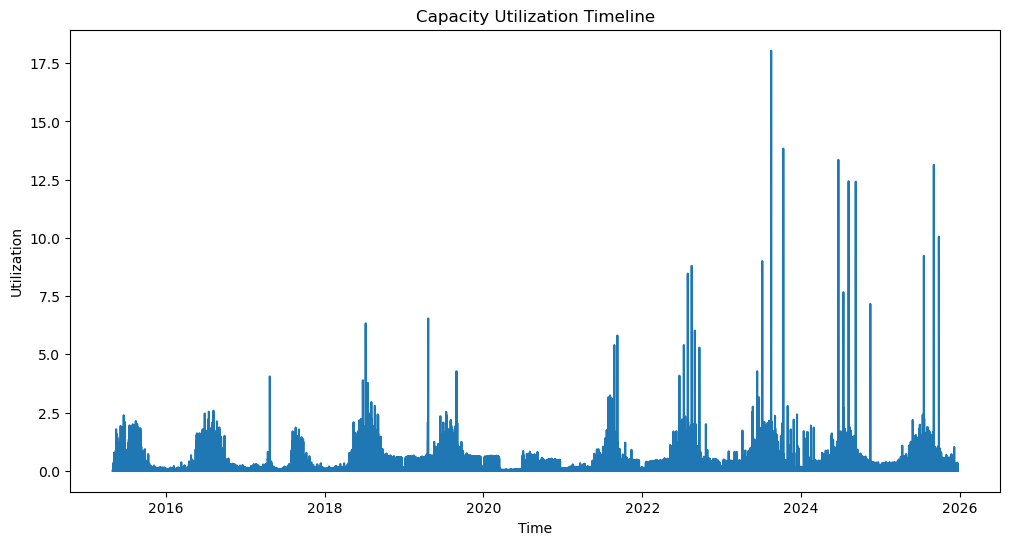

In [14]:
# Capacity Utilization Timeline
plt.figure(figsize=(12,6))
plt.plot(df_processed['Timestamp'], df_processed['Capacity_Utilization'])
plt.title("Capacity Utilization Timeline")
plt.xlabel("Time")
plt.ylabel("Utilization")
plt.show()

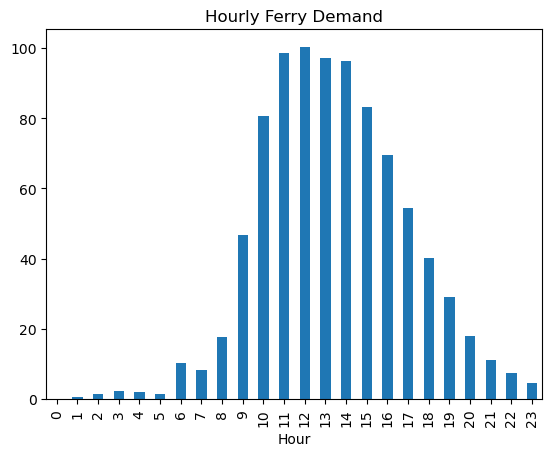

In [15]:
# Hourly Demand Pattern
hourly_pattern = df_processed.groupby('Hour')['Redemption Count'].mean()

hourly_pattern.plot(kind='bar')

plt.title("Hourly Ferry Demand")

plt.show()


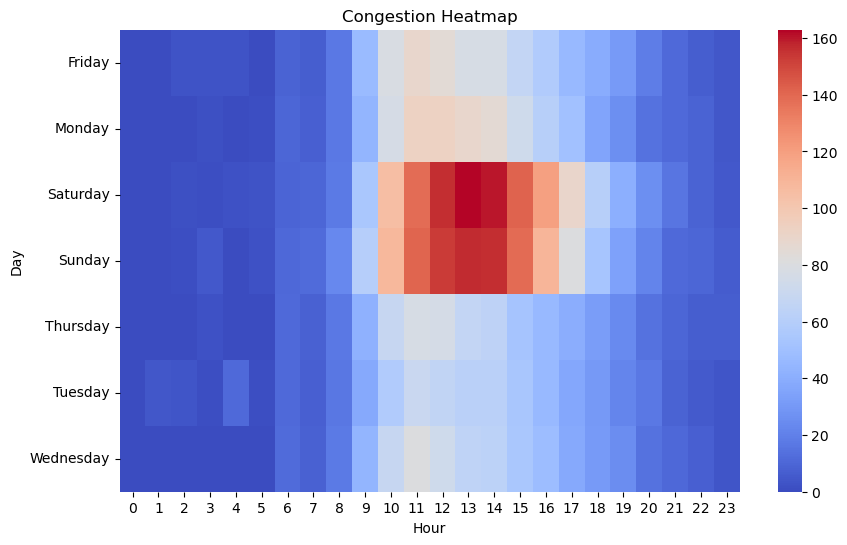

In [16]:
#Congestion Heatmap
heatmap_data = df_processed.pivot_table(
    
    values='Redemption Count',
    
    index='Day',
    
    columns='Hour',
    
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(heatmap_data, cmap="coolwarm")

plt.title("Congestion Heatmap")

plt.show()